# IS 4487 Lab 2

## Outline

- Loading installed packages
- Inspect data
- Explore plot types

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Labs/Scripts/lab_02_megatelco_intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


##Load Libraries

In this class we will be using
- Pandas
- Scikitlearn
- Matplotlib


In [107]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [108]:
import pandas as pd
import matplotlib as mpl
import sklearn as sl

## Megatelco Data Dictionary

 DEMOGRAPHIC VARIABLES:
 - College - has the customer attended some college (one, zero)
 - Income - annual income of customer
 - House - estimated price of the customer's home (if applicable)

 USAGE VARIABLES:
 - Data Overage Mb - Average number of megabytes that the customer used in excess of the plan limit (over last 12 months)
 - Data Leftover Mb - Average number of megabytes that the customer use was below the plan limit (over last 12 months)
 - Data Mb Used - Average number of megabytes used per month (over last 12 months)
 - Text Message Count - Average number of texts per month (over last 12 months)
 - Over 15 Minute Calls Per Month - Average number of calls over 15 minutes in duration per month (over last 12 months)
 - Average Call Duration- Average call duration (over last 12 months)

PHONE VARIABLES:
 - Operating System - Current operating system of phone
 - Handset Price - Retail price of the phone used by the customer

ATTITUDINAL VARIABLES:
 - Reported Satisfaction - Survey response to "How satisfied are you with your current phone plan?" (high, med, low)
 - Reported Usage Level - Survey response to "How much do your use your phone?" (high, med, low)
 - Considering Change of Plan - Survey response to "Are you currently planning to change companies when your contract expires?" (high, med, low)

OTHER VARIABLES
 - Leave - Did this customer churn with the last contract expiration? (LEAVE, STAY)
 - ID - Customer identifier

## Getting data into Pandas
See the Canvas assignments and lectures for a description of the Megatelco data


In [109]:
df = pd.read_csv('https://github.com/Stan-Pugsley/is_4487_base/blob/main/Labs/DataSets/megatelco_leave_survey.csv?raw=true')
print (df)

      college  income  data_overage_mb  data_leftover_mb  data_mb_used  \
0         one  403137               70                 0          6605   
1        zero  129700               67                16          6028   
2        zero   69741               60                 0          1482   
3         one  377572                0                22          3005   
4        zero  382080                0                 0          1794   
...       ...     ...              ...               ...           ...   
14994     one  307114               12                28          4672   
14995     one  429983              312                43          5858   
14996     one  363250              348                82          1812   
14997    zero  221768              334                55          3552   
14998    zero  188472              343                 6          7802   

       text_message_count    house  handset_price  \
0                     199   841317            653   
1    

In [110]:
#look at the top rows
df.head(50)

,college,income,data_overage_mb,data_leftover_mb,data_mb_used,text_message_count,house,handset_price,over_15mins_calls_per_month,average_call_duration,reported_satisfaction,reported_usage_level,considering_change_of_plan,leave,id,operating_system
0,one,403137,70,0,6605,199,841317,653,5.0,8,low,low,yes,LEAVE,8183,Android
1,zero,129700,67,16,6028,134,476664,1193,5.0,5,low,low,yes,LEAVE,12501,IOS
2,zero,69741,60,0,1482,176,810225,1037,3.0,8,low,low,yes,STAY,7425,IOS
3,one,377572,0,22,3005,184,826967,1161,0.0,5,low,low,no,LEAVE,13488,IOS
4,zero,382080,0,0,1794,74,951896,1023,0.0,14,low,low,yes,STAY,11389,IOS
5,zero,309746,0,56,2675,81,1272862,1200,5.0,1,low,high,yes,STAY,14674,IOS
6,one,325592,79,24,7300,190,472330,1083,5.0,6,low,avg,yes,LEAVE,19100,IOS
7,one,131230,0,0,4489,89,613744,365,5.0,10,low,high,yes,STAY,18170,Android
8,one,193667,0,0,1023,76,949829,347,1.0,8,high,low,no,LEAVE,3201,Android
9,one,419573,0,74,4631,209,818027,640,0.0,2,low,low,yes,LEAVE,12612,Android


In [111]:
#look at last rows
df.tail(10)

,college,income,data_overage_mb,data_leftover_mb,data_mb_used,text_message_count,house,handset_price,over_15mins_calls_per_month,average_call_duration,reported_satisfaction,reported_usage_level,considering_change_of_plan,leave,id,operating_system
14989,zero,366948,53,15,3103,131,826132,1129,3.0,16,low,low,yes,LEAVE,21387,IOS
14990,one,214578,272,75,828,169,799938,1206,17.0,17,high,low,yes,STAY,24998,IOS
14991,zero,298032,117,18,4985,215,1190945,283,15.0,5,low,low,no,LEAVE,20554,Android
14992,one,391243,324,14,4853,144,1237571,340,10.0,17,low,low,no,STAY,12285,Android
14993,zero,282020,79,30,7891,155,593067,662,14.0,10,low,low,yes,STAY,9559,Android
14994,one,307114,12,28,4672,104,1086834,375,7.0,8,low,low,yes,STAY,4691,Android
14995,one,429983,312,43,5858,201,378442,1205,12.0,13,low,low,no,LEAVE,9134,IOS
14996,one,363250,348,82,1812,157,443929,1191,19.0,12,low,low,no,LEAVE,10974,IOS
14997,zero,221768,334,55,3552,211,987655,529,11.0,18,low,low,yes,LEAVE,23071,Android
14998,zero,188472,343,6,7802,58,544065,220,8.0,16,low,low,yes,LEAVE,912,Android


In [112]:
#get a summary of the dataset
df.describe()

,income,data_overage_mb,data_leftover_mb,data_mb_used,text_message_count,house,handset_price,over_15mins_calls_per_month,average_call_duration,id
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,1.499900e+04,14999.000000,14996.000000,14999.000000,14999.000000
mean,241989.140476,153.522502,37.522035,4202.624442,135.622041,8.771616e+05,795.146810,10.568685,9.731515,11859.749517
std,109603.370138,113.018111,28.046409,2202.763649,48.831061,2.870316e+05,1235.785429,8.402100,5.195150,6812.842446
min,-65000.000000,0.000000,0.000000,400.000000,52.000000,-4.630000e+02,215.000000,0.000000,1.000000,2.000000
25%,147822.000000,54.000000,12.000000,2294.000000,93.000000,6.444405e+05,498.000000,3.000000,5.000000,6137.000000
50%,241656.000000,151.000000,35.000000,4223.000000,135.000000,8.764130e+05,778.000000,9.000000,10.000000,11760.000000
75%,336456.500000,242.000000,62.000000,6080.000000,178.000000,1.098834e+06,1064.000000,17.000000,14.000000,17396.000000
max,432000.000000,380.000000,89.000000,8000.000000,220.000000,1.456389e+06,125000.000000,35.000000,19.000000,25354.000000


In [113]:
#look at the datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   college                      14999 non-null  object 
 1   income                       14999 non-null  int64  
 2   data_overage_mb              14999 non-null  int64  
 3   data_leftover_mb             14999 non-null  int64  
 4   data_mb_used                 14999 non-null  int64  
 5   text_message_count           14999 non-null  int64  
 6   house                        14999 non-null  int64  
 7   handset_price                14999 non-null  int64  
 8   over_15mins_calls_per_month  14996 non-null  float64
 9   average_call_duration        14999 non-null  int64  
 10  reported_satisfaction        14999 non-null  object 
 11  reported_usage_level         14999 non-null  object 
 12  considering_change_of_plan   14999 non-null  object 
 13  leave           

## Selecting Specific Columns
Square bracket subsetting, or indexing, is a way to access specific rows and columns of a DataFrame. When you use square brackets, [], with a DataFrame you can pass in:

A single column name to select a single column (returns a Series)
A list of column names to select multiple columns (returns a DataFrame)
A boolean mask to select rows based on a condition
A slice to select a range of rows
For example, df['college'] selects the college column as a Series, while df[['college', 'income']] selects the college and income columns as a DataFrame.

In [114]:
df['college']

,college
0,one
1,zero
2,zero
3,one
4,zero
...,...
14994,one
14995,one
14996,one
14997,zero


In [115]:
df[['college', 'income']]

,college,income
0,one,403137
1,zero,129700
2,zero,69741
3,one,377572
4,zero,382080
...,...,...
14994,one,307114
14995,one,429983
14996,one,363250
14997,zero,221768


## Filtering Rows
You create a boolean mask by applying a logical condition to a DataFrame, which returns True/False values. You can then use this mask to select the rows where the condition is True.

In [116]:
df["handset_price"] > 1000

,handset_price
0,False
1,True
2,True
3,True
4,True
...,...
14994,False
14995,True
14996,True
14997,False


## Clean up the data
Did you notice anything unusual about the "house" amounts?

How about the handset price and income?

In [117]:
df_clean = df[(df['house'] > 0) & (df['income'] > 0) & (df['handset_price'] < 10000)]
df_clean.describe()

#lost data at 1000 for the handset price, changed to 10,000

,income,data_overage_mb,data_leftover_mb,data_mb_used,text_message_count,house,handset_price,over_15mins_calls_per_month,average_call_duration,id
count,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,1.499300e+04,14993.00000,14990.000000,14993.000000,14993.000000
mean,242025.183752,153.580804,37.524511,4202.893951,135.626025,8.771541e+05,780.65057,10.571181,9.733676,11862.359501
std,109556.878020,113.002587,28.044642,2202.492183,48.837544,2.869273e+05,326.59192,8.401508,5.194211,6812.221611
min,52491.000000,0.000000,0.000000,400.000000,52.000000,3.200010e+05,215.00000,0.000000,1.000000,2.000000
25%,147844.000000,54.000000,12.000000,2297.000000,93.000000,6.444950e+05,498.00000,3.000000,5.000000,6141.000000
50%,241656.000000,151.000000,35.000000,4223.000000,135.000000,8.762710e+05,778.00000,9.000000,10.000000,11765.000000
75%,336470.000000,242.000000,62.000000,6080.000000,178.000000,1.098785e+06,1064.00000,17.000000,14.000000,17398.000000
max,432000.000000,380.000000,89.000000,8000.000000,220.000000,1.456389e+06,1350.00000,35.000000,19.000000,25354.000000


# Add Derived Attribute

Add a column with the income in K (thousands)

In [118]:
df_clean['income_k'] = (df_clean['income']/1000).round(2)
df_clean.head()
df_clean.describe()

<ipython-input-118-3711b1bb21a7>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['income_k'] = (df_clean['income']/1000).round(2)


,income,data_overage_mb,data_leftover_mb,data_mb_used,text_message_count,house,handset_price,over_15mins_calls_per_month,average_call_duration,id,income_k
count,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,1.499300e+04,14993.00000,14990.000000,14993.000000,14993.000000,14993.000000
mean,242025.183752,153.580804,37.524511,4202.893951,135.626025,8.771541e+05,780.65057,10.571181,9.733676,11862.359501,242.025220
std,109556.878020,113.002587,28.044642,2202.492183,48.837544,2.869273e+05,326.59192,8.401508,5.194211,6812.221611,109.556891
min,52491.000000,0.000000,0.000000,400.000000,52.000000,3.200010e+05,215.00000,0.000000,1.000000,2.000000,52.490000
25%,147844.000000,54.000000,12.000000,2297.000000,93.000000,6.444950e+05,498.00000,3.000000,5.000000,6141.000000,147.840000
50%,241656.000000,151.000000,35.000000,4223.000000,135.000000,8.762710e+05,778.00000,9.000000,10.000000,11765.000000,241.660000
75%,336470.000000,242.000000,62.000000,6080.000000,178.000000,1.098785e+06,1064.00000,17.000000,14.000000,17398.000000,336.470000
max,432000.000000,380.000000,89.000000,8000.000000,220.000000,1.456389e+06,1350.00000,35.000000,19.000000,25354.000000,432.000000


## Summarize the Data
 What is average house price at the two levels of leave?

 Conclusion?  Stayers have substantially more expensive homes.

In [119]:
df_clean[['house','leave']].groupby('leave').mean().round(2)

,house
leave,
LEAVE,757607.46
STAY,995921.88


## Additional Data Preparation

➡️ Assignment Tasks
- Add at least two additional steps to clean or filter the dataset.  Are there any empty values that should be removed?  Can any variables be converted to numbers?

In [120]:
#changing string for 'college' into integers
college = 'college'
college_dict = {
    'zero' : 0,
    'one' : 1,
}
df[college] = pd.to_numeric(df['college'], errors= 'coerce').astype('Int64')
df_clean.head()

,college,income,data_overage_mb,data_leftover_mb,data_mb_used,text_message_count,house,handset_price,over_15mins_calls_per_month,average_call_duration,reported_satisfaction,reported_usage_level,considering_change_of_plan,leave,id,operating_system,income_k
0,one,403137,70,0,6605,199,841317,653,5.0,8,low,low,yes,LEAVE,8183,Android,403.14
1,zero,129700,67,16,6028,134,476664,1193,5.0,5,low,low,yes,LEAVE,12501,IOS,129.70
2,zero,69741,60,0,1482,176,810225,1037,3.0,8,low,low,yes,STAY,7425,IOS,69.74
3,one,377572,0,22,3005,184,826967,1161,0.0,5,low,low,no,LEAVE,13488,IOS,377.57
4,zero,382080,0,0,1794,74,951896,1023,0.0,14,low,low,yes,STAY,11389,IOS,382.08


In [121]:
# prompt: Using dataframe df_clean: suggestion for more filtering that could be done

# Suggestions for more filtering that could be done on the df_clean DataFrame

# 1. Filter by income range:
# Select customers with an income between $100,000 and $200,000
income_filter = df_clean[(df_clean['income'] >= 100000) & (df_clean['income'] <= 200000)]

# 2. Filter by data usage:
# Select customers who used more than 5000 MB of data
data_usage_filter = df_clean[df_clean['data_mb_used'] > 5000]

# 3. Filter by reported satisfaction:
# Select customers who reported high satisfaction
satisfaction_filter = df_clean[df_clean['reported_satisfaction'] == 'high']

# 4. Filter by considering change of plan:
# Select customers considering a change of plan
considering_change_filter = df_clean[df_clean['considering_change_of_plan'] == 'yes']


# 5. Combined filtering:
# Select customers with high income and high data usage
combined_filter = df_clean[(df_clean['income'] > 200000) & (df_clean['data_mb_used'] > 6000)]


# 6. Filter by college:
# Select customer who attended college "one"
college_filter = df_clean[df_clean.college == "one"]


# 7. Filter by operating system:
# Select customers using IOS
os_filter = df_clean[df_clean.operating_system == "IOS"]

# Example: Displaying the first 5 rows of the combined filter
print(combined_filter.head())

   college  income  data_overage_mb  data_leftover_mb  data_mb_used  \
0      one  403137               70                 0          6605   
6      one  325592               79                24          7300   
11     one  310841               74                14          7025   
15    zero  230792              169                 0          7653   
18    zero  221813              216                 0          6803   

    text_message_count   house  handset_price  over_15mins_calls_per_month  \
0                  199  841317            653                          5.0   
6                  190  472330           1083                          5.0   
11                 180  979451            835                          3.0   
15                 196  496113           1281                         10.0   
18                  98  612697           1335                         14.0   

    average_call_duration reported_satisfaction reported_usage_level  \
0                       8       

In [122]:
# Select customers who reported high satisfaction
satisfaction_filter = df_clean[df_clean['reported_satisfaction'] == 'high']
satisfaction_filter.head()

,college,income,data_overage_mb,data_leftover_mb,data_mb_used,text_message_count,house,handset_price,over_15mins_calls_per_month,average_call_duration,reported_satisfaction,reported_usage_level,considering_change_of_plan,leave,id,operating_system,income_k
8,one,193667,0,0,1023,76,949829,347,1.0,8,high,low,no,LEAVE,3201,Android,193.67
10,zero,262085,222,17,530,95,781944,692,10.0,1,high,high,yes,LEAVE,3266,Android,262.08
11,one,310841,74,14,7025,180,979451,835,3.0,5,high,low,no,STAY,13155,IOS,310.84
16,one,236152,0,21,3881,189,1364832,745,13.0,6,high,low,yes,STAY,3335,Android,236.15
17,one,422168,0,10,794,213,909127,874,1.0,4,high,low,yes,STAY,80,IOS,422.17


## Data Visualization

➡️ Assignment Tasks
- Add at least two charts to show a summary of any major trends

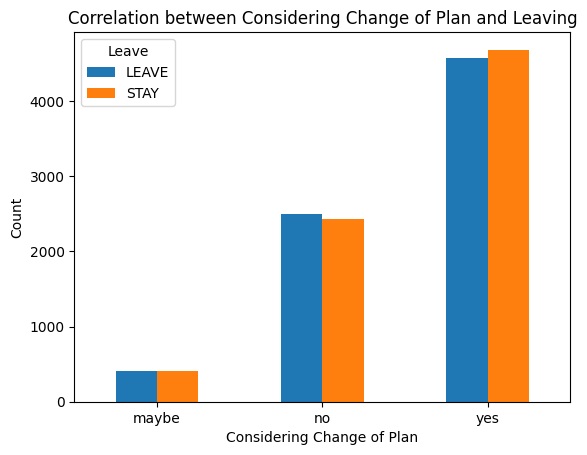

In [123]:
# Chart to show correlation between considering_change_of_plan with leave group

# Create a cross-tabulation of 'considering_change_of_plan' and 'leave'
crosstab = pd.crosstab(df_clean['considering_change_of_plan'], df_clean['leave'])

# Plotting the correlation using a bar chart
crosstab.plot(kind='bar')
plt.title('Correlation between Considering Change of Plan and Leaving')
plt.xlabel('Considering Change of Plan')
plt.ylabel('Count')
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability
plt.legend(title='Leave')
plt.show()



(array([0, 1]), [Text(0, 0, 'LEAVE'), Text(1, 0, 'STAY')])

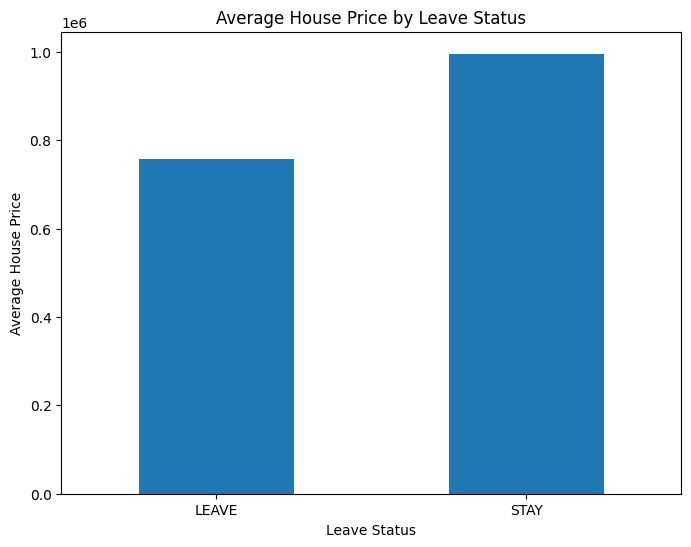

In [124]:
# Average house price for each 'leave' group
average_house_price_by_leave = df_clean.groupby('leave')['house'].mean()

plt.figure(figsize=(8, 6))
average_house_price_by_leave.plot(kind='bar')
plt.title('Average House Price by Leave Status')
plt.xlabel('Leave Status')
plt.ylabel('Average House Price')
plt.xticks(rotation=0)

(array([0, 1]), [Text(0, 0, 'LEAVE'), Text(1, 0, 'STAY')])

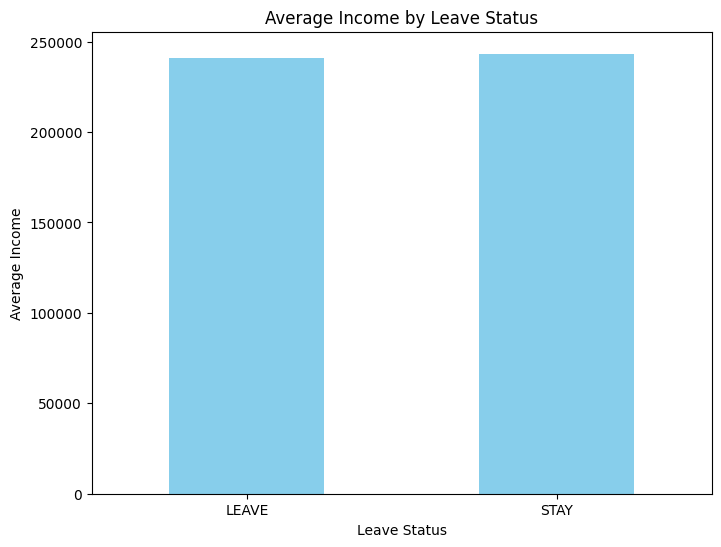

In [125]:
# average income for each 'leave' group
average_income_by_leave = df_clean.groupby('leave')['income'].mean()


plt.figure(figsize=(8, 6))
average_income_by_leave.plot(kind='bar', color='skyblue')
plt.title('Average Income by Leave Status')
plt.xlabel('Leave Status')
plt.ylabel('Average Income')
plt.xticks(rotation=0)